In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
import random
random.seed(42)
np.random.seed(42)

n = 500

neighborhoods = ['University City', 'South End', 'NoDa', 'Steele Creek', 'Ballantyne', 
                 'East Charlotte', 'Mooresville', 'Matthews', 'Huntersville', 'Concord']

data = {
    'neighborhood': [random.choice(neighborhoods) for _ in range(n)],
    'data_center_size_mw': np.round(np.random.uniform(10, 500, n), 1),
    'existing_grid_load_pct': np.round(np.random.uniform(40, 95, n), 1),
    'distance_to_substation_miles': np.round(np.random.uniform(0.5, 15, n), 2),
    'residential_density': np.round(np.random.uniform(1, 10, n), 1),
    'num_existing_data_centers': np.random.randint(0, 8, n),
}

def classify_stress(row):
    score = 0
    if row['data_center_size_mw'] > 300: score += 3
    elif row['data_center_size_mw'] > 150: score += 2
    else: score += 1
    if row['existing_grid_load_pct'] > 80: score += 3
    elif row['existing_grid_load_pct'] > 65: score += 2
    else: score += 1
    if row['distance_to_substation_miles'] > 10: score += 2
    else: score += 1
    if row['num_existing_data_centers'] > 4: score += 2
    else: score += 1
    if score >= 8: return 'High'
    elif score >= 5: return 'Medium'
    else: return 'Low'

data['grid_stress_level'] = pd.DataFrame(data).apply(classify_stress, axis=1)
df = pd.DataFrame(data)

print(df.head(10))
print("\nStress level breakdown:")
print(df['grid_stress_level'].value_counts())

      neighborhood  data_center_size_mw  existing_grid_load_pct  \
0        South End                193.5                    78.4   
1  University City                475.9                    69.5   
2       Ballantyne                368.7                    57.0   
3     Steele Creek                303.3                    84.8   
4     Steele Creek                 86.4                    77.7   
5             NoDa                 86.4                    48.9   
6        South End                 38.5                    90.1   
7     Huntersville                434.4                    85.2   
8        South End                304.5                    92.2   
9          Concord                357.0                    79.9   

   distance_to_substation_miles  residential_density  \
0                          3.18                  5.7   
1                          8.36                  5.3   
2                         13.16                  1.2   
3                         11.12       

In [4]:
from sklearn.preprocessing import LabelEncoder

le_neighborhood = LabelEncoder()
df['neighborhood_encoded'] = le_neighborhood.fit_transform(df['neighborhood'])

le_stress = LabelEncoder()
df['stress_encoded'] = le_stress.fit_transform(df['grid_stress_level'])

features = ['neighborhood_encoded', 'data_center_size_mw', 'existing_grid_load_pct', 
            'distance_to_substation_miles', 'residential_density', 'num_existing_data_centers']

X = df[features]
y = df['stress_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Stress classes: {le_stress.classes_}")

Training samples: 400
Testing samples: 100
Stress classes: ['High' 'Low' 'Medium']


In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully!")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_stress.classes_))

Model trained successfully!

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.79      0.88        24
         Low       1.00      1.00      1.00         5
      Medium       0.93      1.00      0.97        71

    accuracy                           0.95       100
   macro avg       0.98      0.93      0.95       100
weighted avg       0.95      0.95      0.95       100



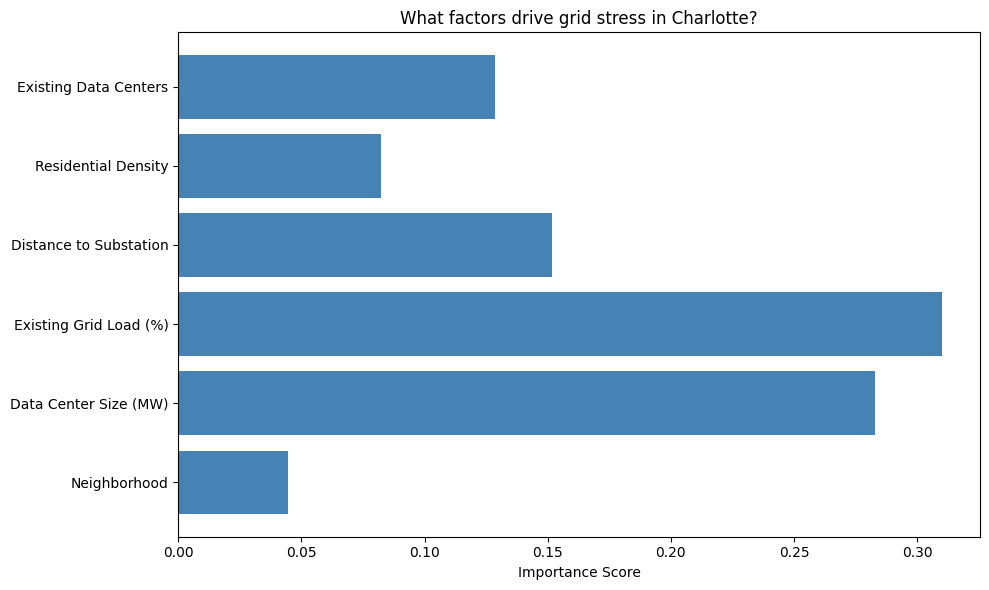


Top factors:
  Existing Grid Load (%): 0.310
  Data Center Size (MW): 0.283
  Distance to Substation: 0.152
  Existing Data Centers: 0.129
  Residential Density: 0.082
  Neighborhood: 0.044


In [6]:
feature_names = ['Neighborhood', 'Data Center Size (MW)', 'Existing Grid Load (%)', 
                 'Distance to Substation', 'Residential Density', 'Existing Data Centers']

importances = model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='steelblue')
plt.xlabel('Importance Score')
plt.title('What factors drive grid stress in Charlotte?')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("\nTop factors:")
for name, score in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {score:.3f}")

In [7]:
def predict_stress(neighborhood, size_mw, grid_load_pct, distance_miles, density, existing_centers):
    hood_encoded = le_neighborhood.transform([neighborhood])[0]
    input_data = pd.DataFrame([[hood_encoded, size_mw, grid_load_pct, distance_miles, density, existing_centers]],
                               columns=features)
    prediction = model.predict(input_data)[0]
    stress_label = le_stress.inverse_transform([prediction])[0]
    proba = model.predict_proba(input_data)[0]
    
    print(f"\nPrediction for a {size_mw}MW data center in {neighborhood}:")
    print(f"  Grid Stress Level: {stress_label}")
    print(f"  Confidence: {max(proba)*100:.1f}%")
    for label, prob in zip(le_stress.classes_, proba):
        print(f"    {label}: {prob*100:.1f}%")

predict_stress('East Charlotte', 300, 88, 5.0, 7.0, 3)
predict_stress('Ballantyne', 50, 45, 2.0, 3.0, 1)


Prediction for a 300MW data center in East Charlotte:
  Grid Stress Level: Medium
  Confidence: 60.0%
    High: 40.0%
    Low: 0.0%
    Medium: 60.0%

Prediction for a 50MW data center in Ballantyne:
  Grid Stress Level: Low
  Confidence: 64.0%
    High: 0.0%
    Low: 64.0%
    Medium: 36.0%


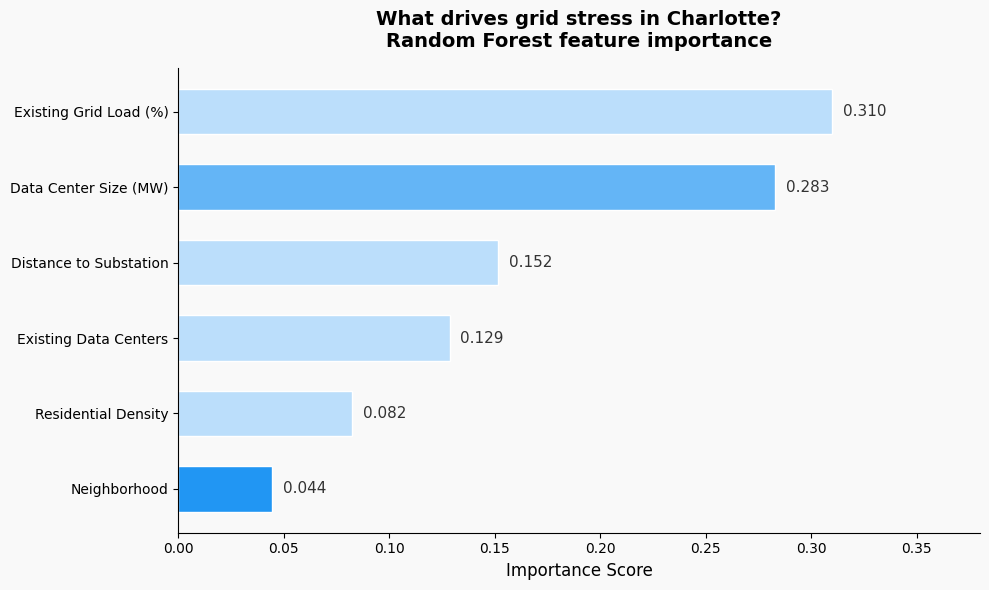

Chart saved!


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2196F3' if i == 0 else '#64B5F6' if i == 1 else '#BBDEFB' 
          for i in range(len(importances))]

sorted_idx = sorted(range(len(importances)), key=lambda i: importances[i])
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_scores = [importances[i] for i in sorted_idx]
sorted_colors = [colors[i] for i in sorted_idx]

bars = ax.barh(sorted_names, sorted_scores, color=sorted_colors, edgecolor='white', height=0.6)

for bar, score in zip(bars, sorted_scores):
    ax.text(score + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=11, color='#333333')

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('What drives grid stress in Charlotte?\nRandom Forest feature importance', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 0.38)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")